## Studying 2D Turbulence with the Scattering Transform ##
**J.W.Skinner, Caltech, 2024**

This notebook demonstrates how the 2D scattering transform can be used to generate and optimize random fields based on a 2D turbulence simulation. 

In particular, it studies how varying the second-order scattering coefficients summary statistics: $s_{21}$ and $s_{22}$ affects the turbulence field's structure while keeping the power spectrum fixed.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.fft
import netCDF4 as nc
from scipy.ndimage import zoom
import cmocean
import time
import sys
sys.path.append('/home/jskinner1/scattering_transform')
import scattering
import ST
if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
else:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(device)

use torch backend
cuda


### Import data and structure it for the ST analysis

In [2]:
# Import the tuburlence data 
torch.cuda.empty_cache()

# ------- Input data ------
datapath = "./JWS_turb_data/"

imin = 90  # starting index
imax = 99  # ending index

with nc.Dataset(datapath + f"output_0{imin:03d}.nc", "r") as file:
    nx = file.dimensions["nx"].size
    ny = file.dimensions["nx"].size

image = np.zeros(((imax - imin + 1), nx, ny))

for i in range(imin, imax + 1):
    filename = datapath + f"output_0{i:03d}.nc"  
    with nc.Dataset(filename, "r") as file:
        z = file.variables["z"][:]
        image[i - imin] = z

In [3]:
# Calculate the SCs of the input image 
def calculate_scattering_coefficients(image, M = 256, N = 256, J=8, L=4):
    imnew = torch.unsqueeze(image, dim=0) 
    filters_set = ST.FiltersSet(M=M, N=N, J=J, L=L).generate_morlet(if_save=False, save_dir=None, precision='single')
    ST_calculator = ST.ST_2D(filters_set, J, L)
    S, S0, S1, S2, C00, E_residual, L2, _ = ST_calculator.forward(imnew, J, L)

    S1_iso =  S1.mean(-1)
    S2_red = torch.zeros((imnew.shape[0],J,J,L), dtype=imnew.dtype)

    for l1 in range(L):
        for l2 in range(L):
                S2_red [:,:,:,(l2-l1)%L] += S2[:,:,l1,:,l2]
    S2_red /= L

    s21 = S2_red.mean(-1) / S1_iso[:,:,None]
    s22 = S2_red[:,:,:,0] / S2_red[:,:,:,L//2]
    return s21, s22

im_input = torch.tensor(image[0]).requires_grad_()
input_S21, input_S22 = calculate_scattering_coefficients(im_input, M = im_input.shape[0], N = im_input.shape[1], J=8, L=8)

/home/jskinner1/miniconda3/envs/be/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647406761/work/aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


### Optimize the field by gradient descent to match some prescribed s22 and 21 values

In [4]:
import numpy as np
import torch
import torch.fft as fft
import matplotlib.pyplot as plt


def optimize_s21_s22(image, target_S21, target_S22, max_iterations=10, learning_rate=1e-2, loss_type='both', device = device):
    """
    Optimizes a field to match target scattering coefficients by directly
    manipulating the Fourier phase, preserving the power spectrum.
    """

    image_tensor = torch.tensor(image, dtype=torch.float32)
    image_tensor = image_tensor[0]  # Use first frame if shape (T, H, W)
        
    H, W = image_tensor.shape

    # Compute target amplitude spectrum (fixed constraint)
    image_fft = fft.fft2(image_tensor)
    target_amplitude = torch.abs(image_fft)

    # Initialize the Fourier phase (the variable to be optimized)
    initial_phase = torch.angle(image_fft)
    phase = initial_phase.clone().detach().requires_grad_()

    # Set up the optimizer to act directly on the phase 
    optimizer = torch.optim.Adam([phase], lr=learning_rate)

    for i in range(max_iterations):
        optimizer.zero_grad()

        # Construct the field from the current phase and target amplitude
        # This step inherently enforces the power spectrum constraint.
        complex_phase = torch.cos(phase) + 1j * torch.sin(phase)
        fft_current = target_amplitude * complex_phase
        grf_current = fft.ifft2(fft_current).real

        # Compute scattering coefficients for the current field
        current_S21, current_S22 = calculate_scattering_coefficients(
            grf_current, M=H, N=W, J=8, L=4
        )

        # Calculate the loss / total mean 
        loss_s21 = torch.nanmean((current_S21 - target_S21)**2)
        loss_s22 = torch.nanmean((current_S22 - target_S22)**2)
        
        # We could also calculate the loss as ratio so preserving each (j1, j2) component
        # scale_s21 = torch.nanmean(target_S21 / (current_S21 + 1e-8))
        # scale_s22 = torch.nanmean(target_S22 / (current_S22 + 1e-8))
        # loss_s21 = (scale_s21 - 1)**2
        # loss_s22 = (scale_s22 - 1)**2
        
        if loss_type == 'both':
            loss = loss_s21 + loss_s22
        elif loss_type == 's21':
            loss = loss_s21
        elif loss_type == 's22':
            loss = loss_s22         

        if i % 10 == 0:
            print(f"Iteration {i}, Loss: {loss.item():.4e}")

        if loss.item() < 1e-6:
            print("Convergence reached.")
            break

        # Update the phase via gradient descent
        # Here gradients are computed with respect to the phase and the optimizer updates it.
        loss.backward()
        optimizer.step()

    # Construct the final field from the optimized phase
    with torch.no_grad():
        final_complex_phase = torch.cos(phase) + 1j * torch.sin(phase)
        final_fft = target_amplitude * final_complex_phase
        optimized_field = fft.ifft2(final_fft).real

    return optimized_field

#### Vary s22 and s21 by e.g., ±25% and optimize for those fields

In [ ]:
target_S21 = input_S21.detach()
target_S22 = input_S22.detach()

optimized_grf_s22high = optimize_s21_s22(image, target_S21, 1.75 * target_S22, max_iterations=200, learning_rate=1e-1, loss_type='s22')
optimized_grf_s22low  = optimize_s21_s22(image, target_S21, 0.25 * target_S22, max_iterations=200, learning_rate=1e-1, loss_type='s22')
optimized_grf_s21high = optimize_s21_s22(image, 1.75 * target_S21, target_S22, max_iterations=200, learning_rate=1e-1, loss_type='s21')
optimized_grf_s21low  = optimize_s21_s22(image, 0.25 * target_S21, target_S22, max_iterations=200, learning_rate=1e-1, loss_type='s21')

Iteration 0, Loss: 1.2696e+00
Iteration 10, Loss: 3.2741e-01
Iteration 20, Loss: 1.4465e-01
Iteration 30, Loss: 7.0742e-02


### Plot the generated fields

/var/folders/wl/4n95mfbn2z74qd0g0g9_58g00000gq/T/ipykernel_58969/1796513163.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


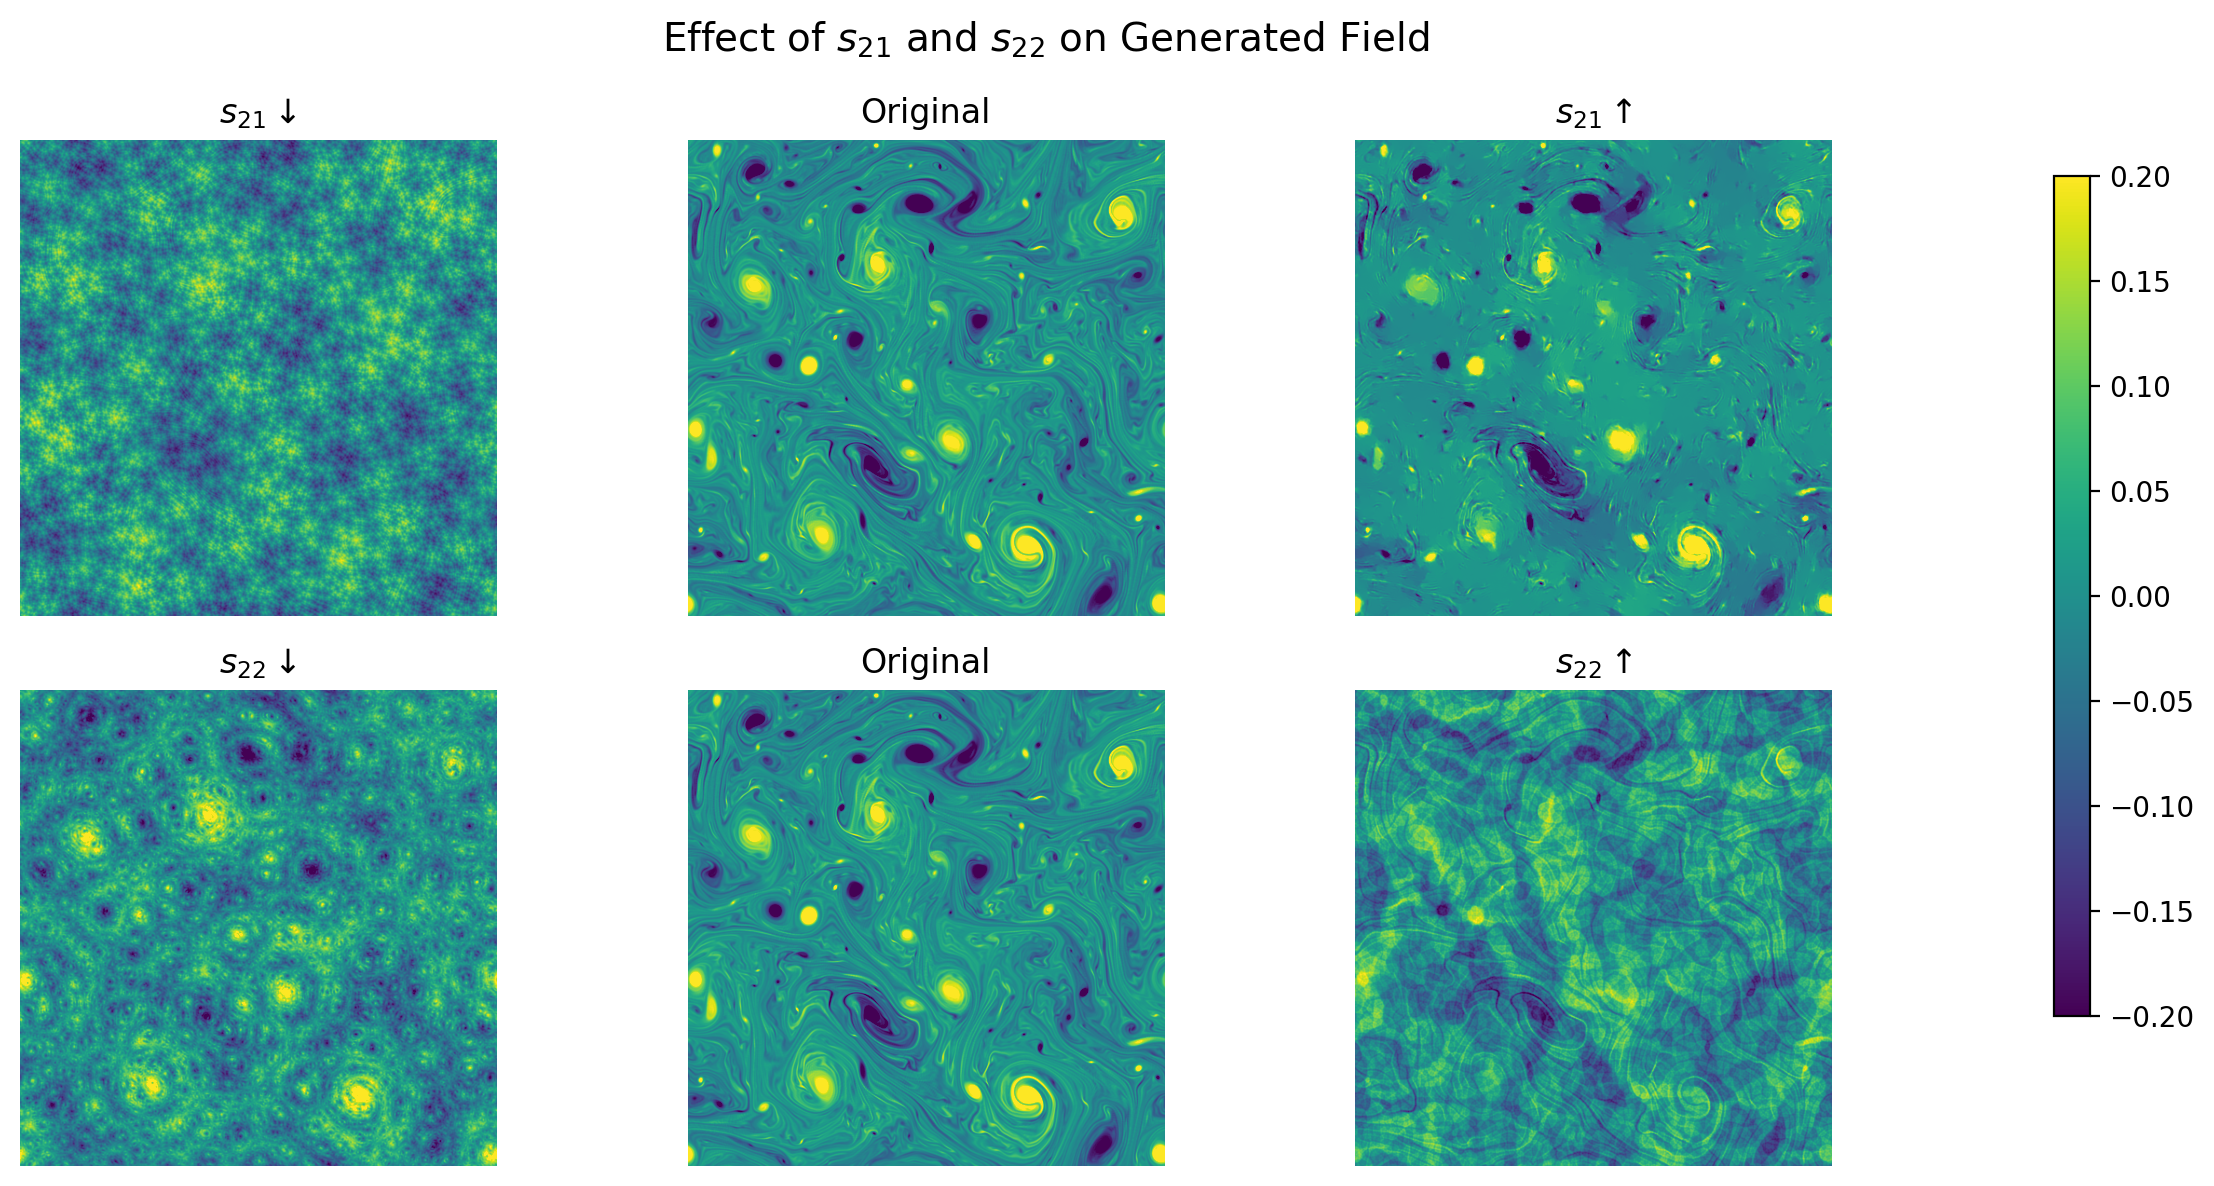

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def to_numpy(x):
    if hasattr(x, "detach"):  # torch.Tensor
        return x.detach().cpu().numpy()
    return x  # assume already numpy


fields_grid = [
    [optimized_grf_s21low, image[0], optimized_grf_s21high],
    [optimized_grf_s22low, image[0], optimized_grf_s22high]
]

titles_grid = [
    [r"$s_{21} \downarrow$", "Original", r"$s_{21} \uparrow$"],
    [r"$s_{22} \downarrow$", "Original", r"$s_{22} \uparrow$"]
]


# Plot 
vmin = -0.2 #1.3*to_numpy(image[0]).min()
vmax = 0.2 #0.7*to_numpy(image[0]).max()

fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=200)
for i in range(2):
    for j in range(3):
        ax = axes[i, j]
        field = to_numpy(fields_grid[i][j])
        im = ax.imshow(field, cmap='viridis', vmin=vmin, vmax=vmax, origin='lower')
        ax.set_title(titles_grid[i][j], fontsize=12)
        ax.axis('off')

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax)

fig.suptitle("Effect of $s_{21}$ and $s_{22}$ on Generated Field", fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()
